C:\Users\Almazt\AppData\Local\Temp\ipykernel_24184\3900869116.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


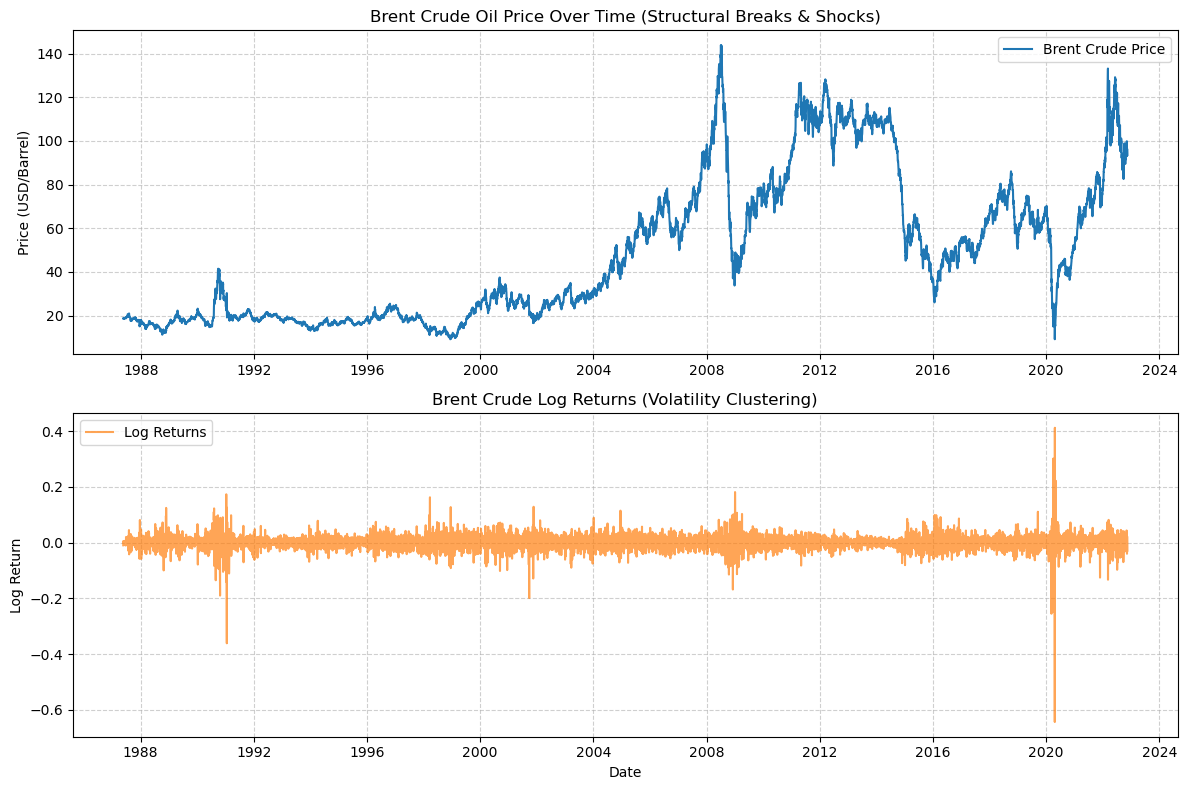

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# 1. Load and Clean Data
# Assuming 'BrentOilPrices.csv' has columns 'Date' and 'Price'
df = pd.read_csv('../data/raw/BrentOilPrices.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 2. Add time index for the PyMC model
df['Time_Idx'] = np.arange(len(df))

# 3. Calculate Log Returns for EDA volatility observation
df['Log_Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))

# --- Plot Request 1: EDA Visualizations ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Raw Price Series
axes[0].plot(df['Date'], df['Price'], color='tab:blue', label='Brent Crude Price')
axes[0].set_title('Brent Crude Oil Price Over Time (Structural Breaks & Shocks)')
axes[0].set_ylabel('Price (USD/Barrel)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot Log Returns
axes[1].plot(df['Date'], df['Log_Return'], color='tab:orange', alpha=0.7, label='Log Returns')
axes[1].set_title('Brent Crude Log Returns (Volatility Clustering)')
axes[1].set_ylabel('Log Return')
axes[1].set_xlabel('Date')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Extract numpy arrays for PyMC
time_idx = df['Time_Idx'].values
prices = df['Price'].values
n_days = len(df)

with pm.Model() as change_point_model:
    # 1. Priors for the switch point (Discrete Uniform over all index positions)
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_days - 1)
    
    # 2. Priors for the mean prices before and after the switch
    # Using normal priors around the dataset's overall mean
    price_mean = np.mean(prices)
    price_std = np.std(prices)
    mu_1 = pm.Normal("mu_1", mu=price_mean, sigma=price_std)
    mu_2 = pm.Normal("mu_2", mu=price_mean, sigma=price_std)
    
    # 3. Priors for standard deviation before and after (capturing variance shifts)
    sigma_1 = pm.HalfNormal("sigma_1", sigma=price_std)
    sigma_2 = pm.HalfNormal("sigma_2", sigma=price_std)
    
    # 4. Deterministic switch function
    # If time_idx < tau, use mu_1/sigma_1; else use mu_2/sigma_2
    mu_ = pm.math.switch(tau > time_idx, mu_1, mu_2)
    sigma_ = pm.math.switch(tau > time_idx, sigma_1, sigma_2)
    
    # 5. Likelihood
    likelihood = pm.Normal("likelihood", mu=mu_, sigma=sigma_, observed=prices)
    
    # 6. Sampling (MCMC)
    # PyMC automatically assigns Metropolis for discrete variables (tau) and NUTS for continuous ones
    trace = pm.sample(draws=2000, tune=1500, return_inferencedata=True, random_seed=42)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma_1, sigma_2]


c:\Users\Almazt\AppData\Local\anaconda3\envs\brent_oil\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 29 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


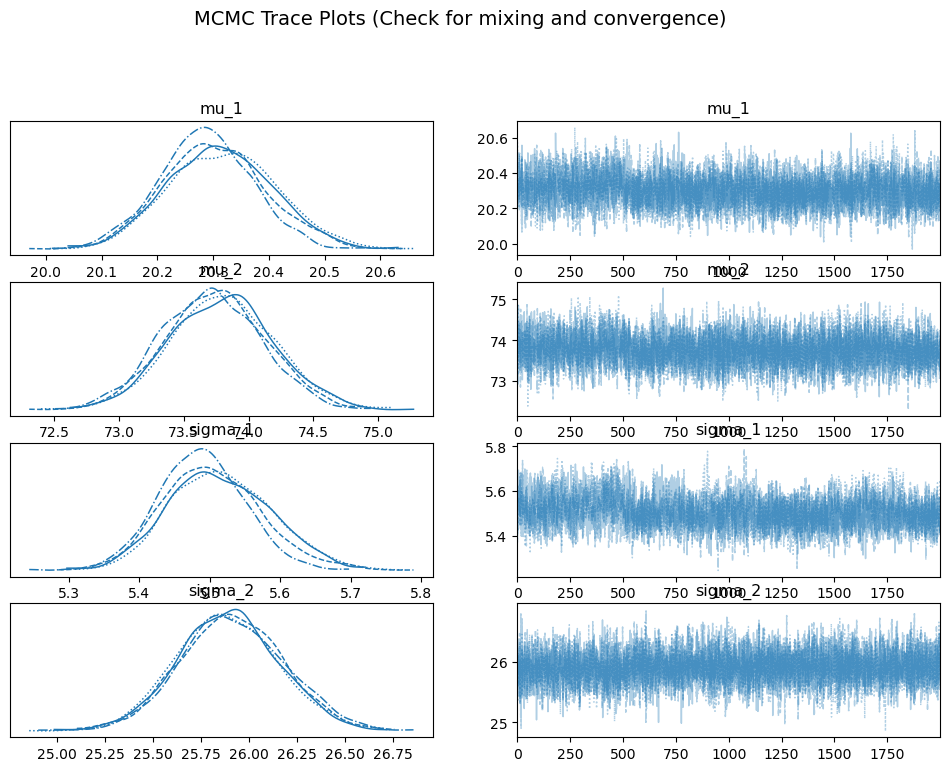

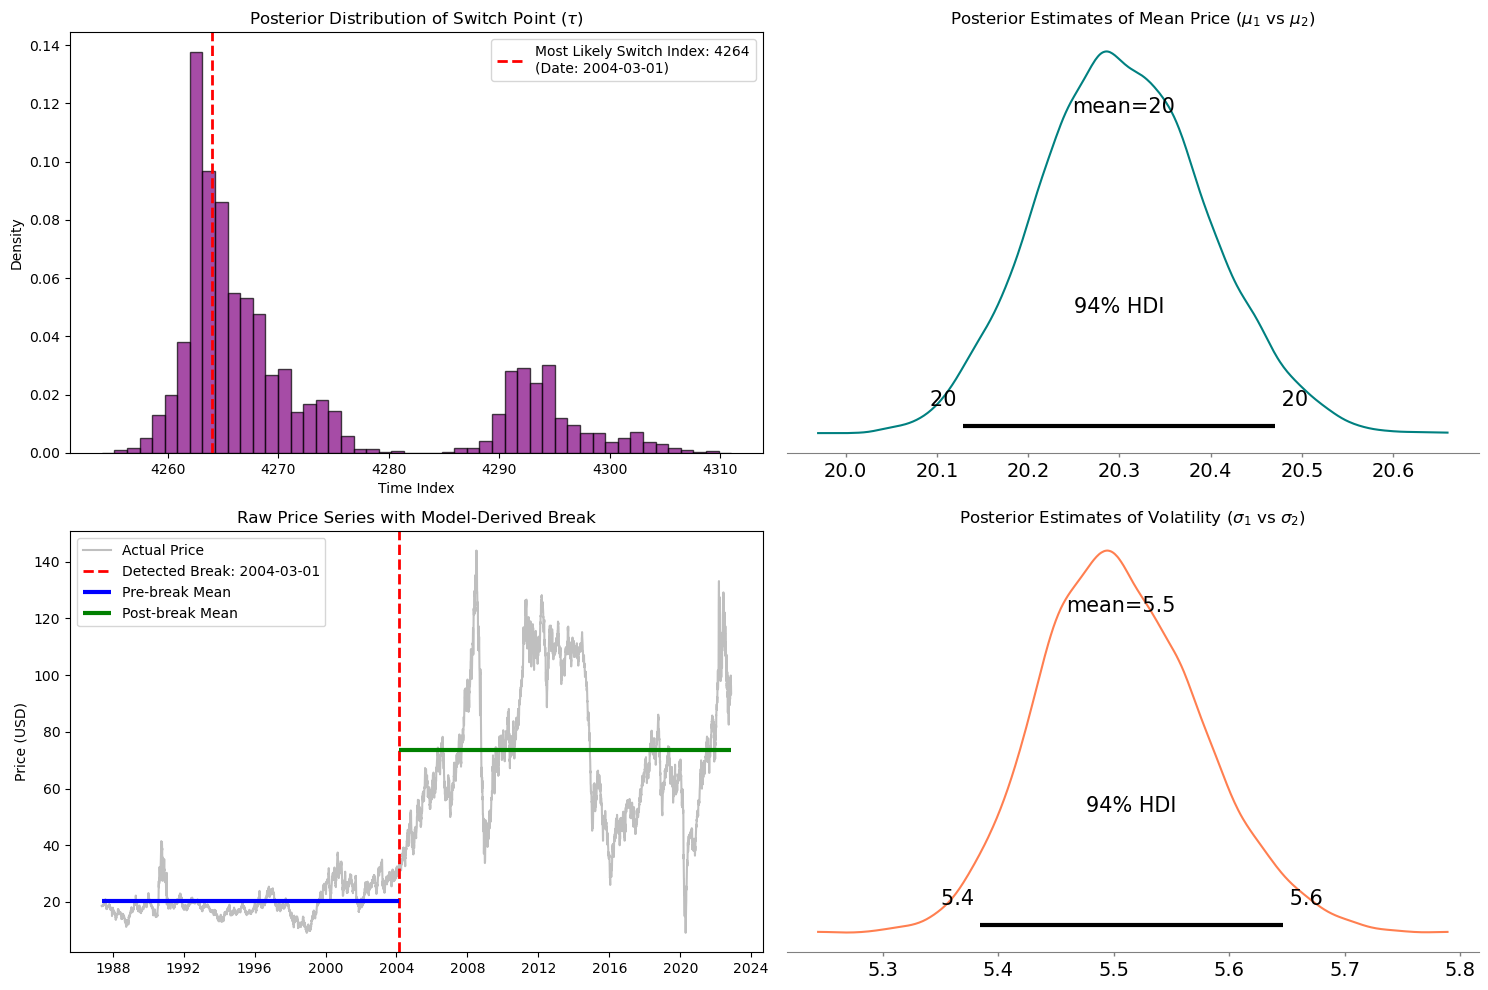


--- Convergence Summary (Look for r_hat ~ 1.0) ---
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_1     20.304  0.091  20.129   20.471      0.009    0.001     114.0   
mu_2     73.763  0.392  73.064   74.544      0.019    0.004     408.0   
sigma_1   5.506  0.070   5.385    5.646      0.009    0.002      63.0   
sigma_2  25.902  0.267  25.428   26.425      0.005    0.003    3069.0   

         ess_tail  r_hat  
mu_1       1013.0   1.03  
mu_2       2906.0   1.01  
sigma_1     285.0   1.04  
sigma_2    6123.0   1.00  


In [5]:
# --- Plot Request 2: Diagnostic & Posterior Inference Visualizations ---

# 1. Convergence Diagnostics (Trace Plots)
az.plot_trace(trace, var_names=["mu_1", "mu_2", "sigma_1", "sigma_2"])
plt.suptitle("MCMC Trace Plots (Check for mixing and convergence)", y=1.02, fontsize=14)
plt.show()

# 2. High-Impact Custom Visualizations: Change Point & Parameter Shifts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# A. Posterior Distribution of Tau (The Switch Point)
posterior_tau = trace.posterior["tau"].values.flatten()
axes[0, 0].hist(posterior_tau, bins=50, color="purple", alpha=0.7, edgecolor="black", density=True)
axes[0, 0].set_title("Posterior Distribution of Switch Point ($\\tau$)")
axes[0, 0].set_xlabel("Time Index")
axes[0, 0].set_ylabel("Density")

# Map the most likely time index back to a real calendar date
mode_tau = int(pd.Series(posterior_tau).mode()[0])
detected_date = df.loc[mode_tau, 'Date'].strftime('%Y-%m-%d')
axes[0, 0].axvline(mode_tau, color='red', linestyle='--', linewidth=2, 
                   label=f'Most Likely Switch Index: {mode_tau}\n(Date: {detected_date})')
axes[0, 0].legend()

# B. Posterior Distribution of Means (Comparing Price Distributions)
az.plot_posterior(trace, var_names=["mu_1", "mu_2"], ax=axes[0, 1], color="teal")
axes[0, 1].set_title("Posterior Estimates of Mean Price ($\mu_1$ vs $\mu_2$)")

# C. Actual Price with Detected Change Point Overlay
axes[1, 0].plot(df['Date'], df['Price'], color='gray', alpha=0.5, label='Actual Price')
axes[1, 0].axvline(df.loc[mode_tau, 'Date'], color='red', linestyle='--', linewidth=2, 
                   label=f'Detected Break: {detected_date}')

# Calculate posterior mean averages for visualization overlay
mu1_mean = trace.posterior["mu_1"].mean().values
mu2_mean = trace.posterior["mu_2"].mean().values
axes[1, 0].hlines(mu1_mean, xmin=df['Date'].min(), xmax=df.loc[mode_tau, 'Date'], color='blue', linewidth=3, label='Pre-break Mean')
axes[1, 0].hlines(mu2_mean, xmin=df.loc[mode_tau, 'Date'], xmax=df['Date'].max(), color='green', linewidth=3, label='Post-break Mean')

axes[1, 0].set_title("Raw Price Series with Model-Derived Break")
axes[1, 0].set_ylabel("Price (USD)")
axes[1, 0].legend()

# D. Posterior Distribution of Volatility (Sigma Changes)
az.plot_posterior(trace, var_names=["sigma_1", "sigma_2"], ax=axes[1, 1], color="coral")
axes[1, 1].set_title("Posterior Estimates of Volatility ($\sigma_1$ vs $\sigma_2$)")

plt.tight_layout()
plt.show()

# Print formal summary metrics to check for R-hat convergence
print("\n--- Convergence Summary (Look for r_hat ~ 1.0) ---")
print(az.summary(trace, var_names=["mu_1", "mu_2", "sigma_1", "sigma_2"]))